# 04. Photometry at supplied coordinates

Notebooks 01 to 03 measure the MER source list. Here the positions come
from the user: a list from another catalog, or a position where MER has no
entry.

In [1]:
# Locate the package when running from either notebook directory.
import os, sys
from pathlib import Path
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "src/euclid_phot").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from the repository.")
if "euclid_phot" in sys.modules:
    loaded_from = Path(sys.modules["euclid_phot"].__file__).resolve()
    if loaded_from != (PROJECT_ROOT / "src/euclid_phot/__init__.py").resolve():
        raise RuntimeError("Restart the kernel to load this repository's package.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("EUCLID_PHOT_DATA_DIR", str(PROJECT_ROOT / "examples/native_data"))

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from tractor import Tractor

import euclid_phot as ep

DATA_DIR = Path(os.environ["EUCLID_PHOT_DATA_DIR"])
RA, DEC, SIZE_ARCSEC = 269.48, 67.30, 50.0

# Four MER sources of the field and one position 9 arcsec from any of them.
coords = Table(rows=[(269.48742, 67.30611),
                     (269.47947, 67.30433),
                     (269.47445, 67.30173),
                     (269.48088, 67.29698),
                     (269.47300, 67.29850)], names=("ra", "dec"))

## Run the fit

`objects="coords"` replaces the MER query with `user_coords`, and the PSF
comes from the GRID-PSF product, which covers any position. With
`model_selection="tree"` the profile of each source is chosen on the VIS
pixels as in notebook 01; `"point"` or `"exp"` instead fixes one class for
the whole list. Each source starts at 1 microJansky unless the table has a
`flux_ujy` column; with that column the flux guard also rejects fits
above 100 times the given flux.

In [2]:
result = ep.run_forced_photometry(
    RA, DEC, SIZE_ARCSEC,
    prior={"band": "VIS", "objects": "coords", "model_selection": "tree"},
    user_coords=coords,
    target_bands={"euclid": ("Y", "J", "H")},
    mask_bright_stars=True, with_flag=True,
    data_dir=DATA_DIR, n_workers=4, verbose=True,
)

[1/7] using 5 user-supplied source position(s) (no MER query)
[2/7] discover mosaics for VIS, Y, J, H (lazy; only on a cache miss)
[3/7] fetch cutouts: VIS, Y, J, H
[4/7] build per-band PSFs (GRID-PSF, radius=60")
[5/7] build Tractor image + source models on VIS
[5a] STARSIGNAL bright-star mask: 2758 pixels (1.10%) excluded from the VIS fit


[5b] 1 SEP detection(s) share a blob with the supplied positions: modeled as neighbours, not reported


[6/7] VIS fit (free, forced-photometry)
[7/7] NISP forced phot: Y, J, H
[7a] calibrate flux errors (empty-position point-source fits)


  VIS: error inflation x1.06 (empty-position point-source, n=200)
  Y: error inflation x1.00 (empty-position point-source, n=200)
  J: error inflation x1.06 (empty-position point-source, n=200)
  H: error inflation x1.07 (empty-position point-source, n=200)


## What was modeled

The tree detects sources on the VIS image with SEP. A detection that shares
a blob with one of the supplied positions, but matches none of them, is
added to the model as a neighbour so that its light is not absorbed by the
listed source. Only detections of at least 5 sigma that stay clear of the
masked pixels qualify; fainter clumps and the light along a star's masked
spikes are left to the residual. Neighbours are fitted in every band and
then dropped from the result, so the table has one row per supplied
position. Detections in blobs without a listed position are not modeled.
The blank position has no detected blob, so the tree falls back to a point
source fixed at that position with only its flux free.

5 listed sources, 1 neighbour(s)
  neighbour flux in VIS: 0.240 microJansky
  neighbour flux in Y: 0.452 microJansky
  neighbour flux in J: 0.648 microJansky
  neighbour flux in H: 0.556 microJansky


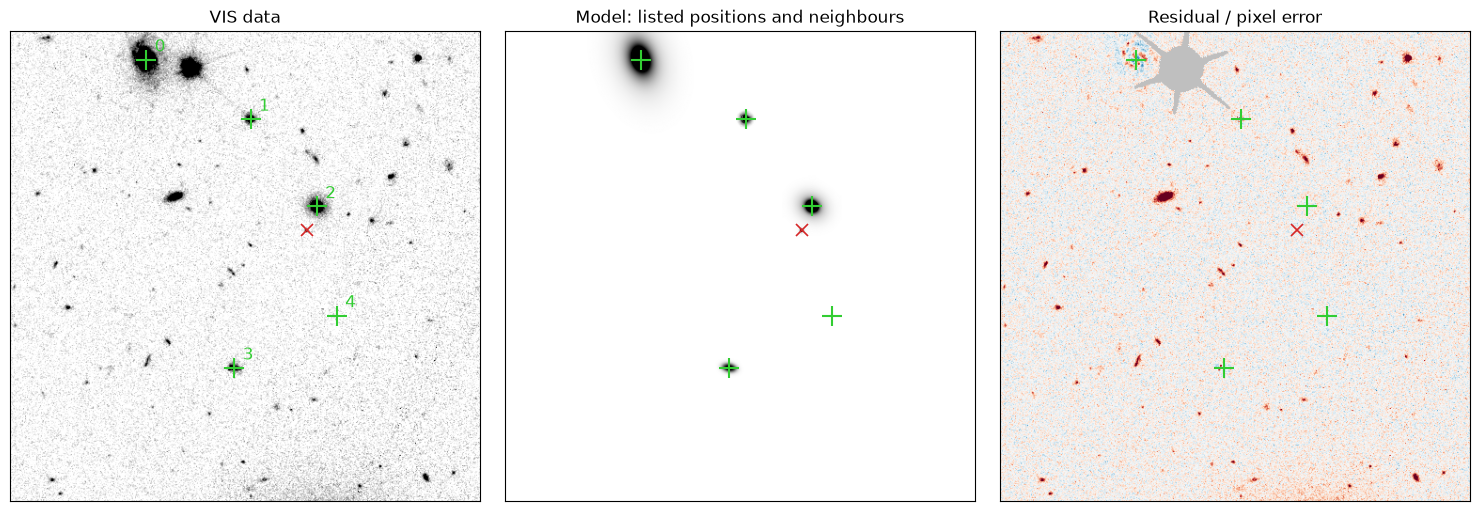

In [3]:
vis = result.cutouts['VIS']
tim = ep.build_tractor_image(vis, psf_data=result.psf_data['VIS'],
                             pixel_mask=result.prior_pixel_mask)
res = ep.measure_residual(Tractor([tim], result.sources + result.neighbour_sources), tim)
px, py = vis.wcs.world_to_pixel_values(coords['ra'], coords['dec'])
nx, ny = vis.wcs.world_to_pixel_values(
    [s.getPosition().ra for s in result.neighbour_sources],
    [s.getPosition().dec for s in result.neighbour_sources])
print(f"{len(result.sources)} listed sources, {len(result.neighbour_sources)} neighbour(s)")
for band, flux in result.neighbour_fluxes_ujy.items():
    print(f"  neighbour flux in {band}: {', '.join(f'{f:.3f}' for f in flux)} microJansky")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmax = float(np.nanpercentile(res['data'], 99.5))
axes[0].imshow(res['data'], origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
axes[0].set_title('VIS data')
axes[1].imshow(res['model'], origin='lower', cmap='gray_r', vmin=0, vmax=vmax)
axes[1].set_title('Model: listed positions and neighbours')
ep.viz.show_chi_map(res['data'], res['model'], tim.getInvvar(),
                    ax=axes[2], title='Residual / pixel error')
for ax in axes:
    ax.plot(px, py, '+', color='limegreen', ms=14, mew=1.5)
    ax.plot(nx, ny, 'x', color='tab:red', ms=8, mew=1.2)
    ax.set_xticks([]); ax.set_yticks([])
for k, (x, y) in enumerate(zip(px, py)):
    axes[0].annotate(str(k), (x, y), xytext=(6, 6), textcoords='offset points',
                     color='limegreen', fontsize=12)
plt.tight_layout()
plt.show()

## The table

One row per input position, in input order. The blank position (row 4)
gets a flux consistent with zero; its error is the sensitivity at that
spot.

In [4]:
catalog = result.to_table(ebv=None)
cols = ["object_id", "ra", "dec", "model", "flux_VIS_ujy", "flux_err_VIS_ujy",
        "flux_Y_ujy", "flux_J_ujy", "flux_H_ujy"]
catalog[cols].pprint_all()

object_id         ra                dec           model         flux_VIS_ujy      flux_err_VIS_ujy        flux_Y_ujy           flux_J_ujy           flux_H_ujy     
                 deg                deg                             uJy                 uJy                  uJy                  uJy                  uJy         
--------- ------------------ ----------------- ------------ ------------------- -------------------- ------------------- --------------------- --------------------
        0 269.48747940363904 67.30612568596521 SersicGalaxy  25.894675021148817   0.1035377504891169   47.57263509141317     56.98851343381839    66.98246839124509
        1  269.4794692665838 67.30433235124524  PointSource   12.57050158938026  0.05545033392148295   38.20970925211134    43.523240303925235   42.228425856454365
        2 269.47445021749223 67.30173299273817 SersicGalaxy  10.985341724739797 0.054126721315857454   25.40730124517267    31.874111665576095   39.030243307279555
        3 269.48

Save with `catalog.write("coordinates_photometry.csv", overwrite=True)`.
For a larger list, keep the positions inside one cutout and one MER tile.